In [ ]:
ofrom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Adult Census Income Notebook

### Data Set Information:
##### Extraction was done by Barry Becker from the 1994 Census database.

##### Prediction task is to determine whether a person makes more 50K a year or less than that.

# Importing Libraries and Dataset

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


<Axes: >

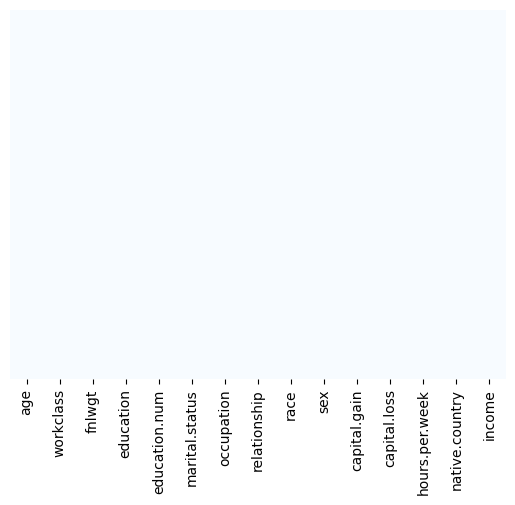

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Blues')

#### So, There are no null values in the dataset

In [ ]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

### Count plot on Income

<Axes: xlabel='income', ylabel='count'>

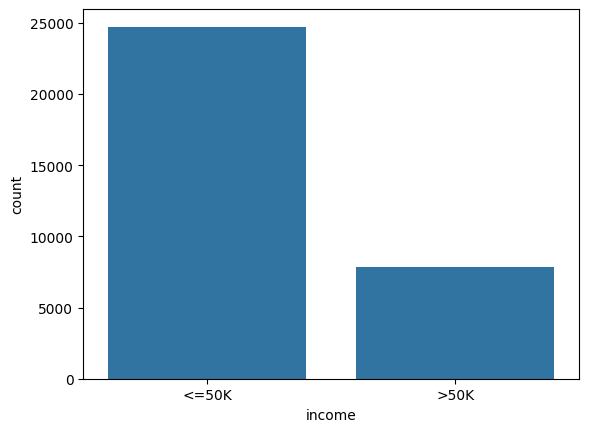

In [ ]:
sns.countplot(x='income', data=df)

### Income Based on Marital Status

<Axes: xlabel='income', ylabel='count'>

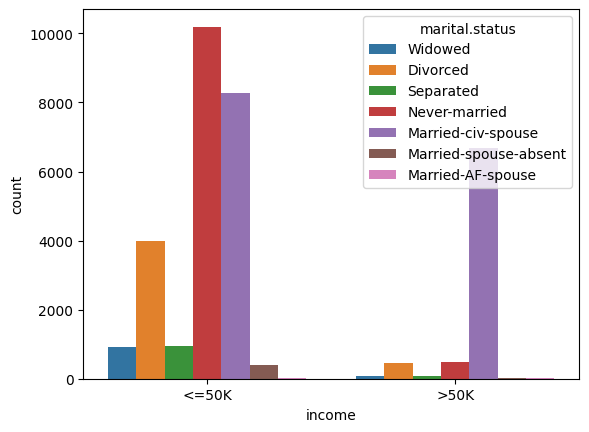

In [ ]:
sns.countplot(x='income', hue='marital.status', data=df)

### Income Based on WorkClass

In [ ]:
df['workclass'].unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

<Axes: xlabel='income', ylabel='count'>

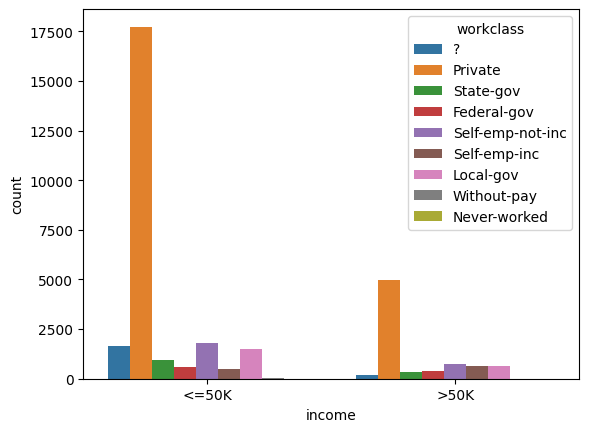

In [ ]:
sns.countplot(x='income', hue='workclass', data=df)

### Income Based on Sex

<Axes: xlabel='income', ylabel='count'>

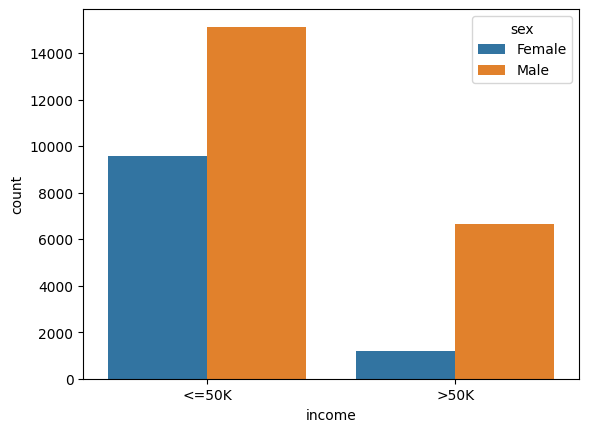

In [ ]:
sns.countplot(x='income', hue='sex', data=df)

### Number of people in each age category

/tmp/ipykernel_318/2526890032.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'].dropna(), kde=False, color='red', bins=40)


<Axes: xlabel='age'>

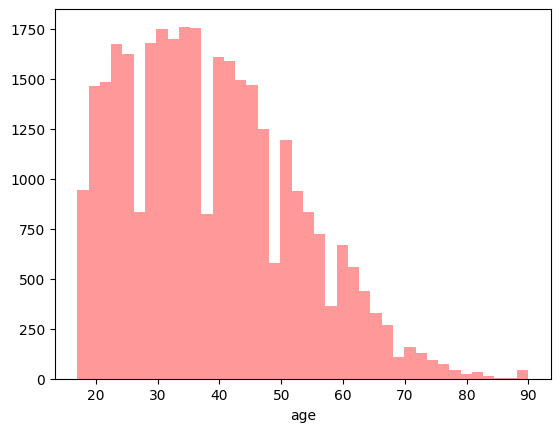

In [ ]:
sns.distplot(df['age'].dropna(), kde=False, color='red', bins=40)

### Income Based on Number of hours a person of certain age is working

<Axes: xlabel='hours.per.week', ylabel='age'>

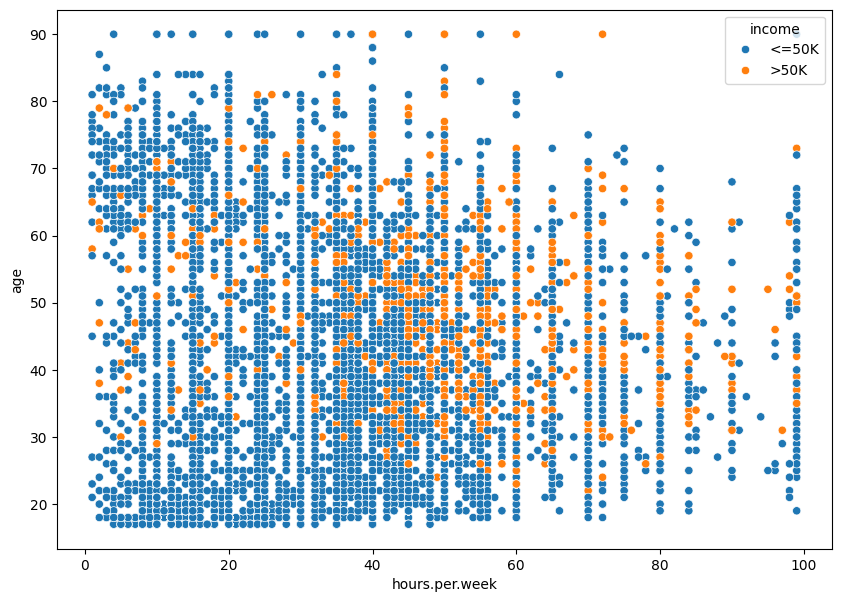

In [ ]:
plt.figure(figsize = (10,7))
sns.scatterplot(x=df['hours.per.week'], y=df['age'], hue=df['income'])

### Income Based on Occupation

/tmp/ipykernel_318/101827241.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(x='income', hue='occupation', data=df, color='red')


<Axes: xlabel='income', ylabel='count'>

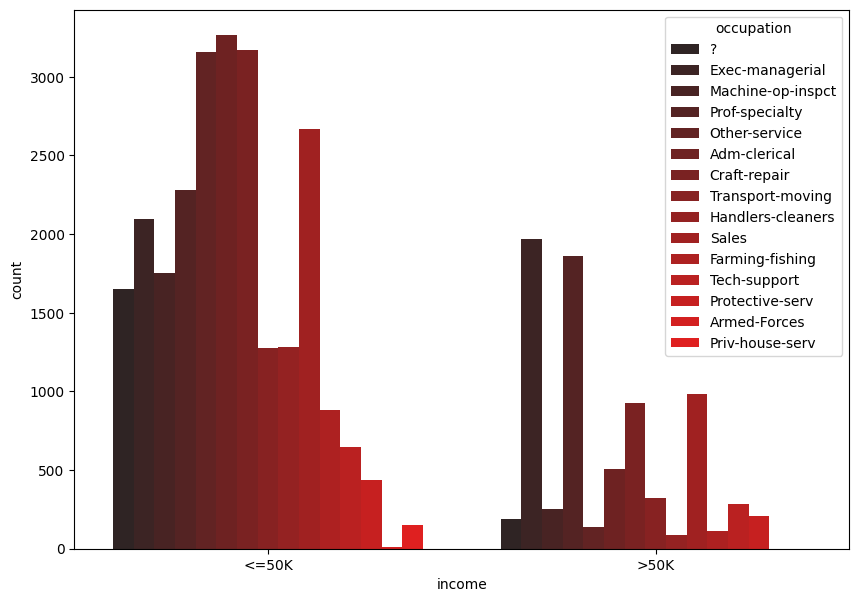

In [ ]:
plt.figure(figsize=(10,7))
sns.countplot(x='income', hue='occupation', data=df, color='red')

### Correlation between variables

<Axes: >

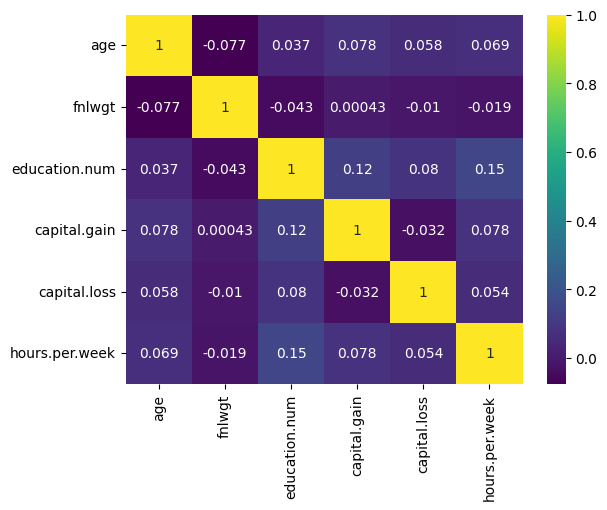

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')

# Feature Engineering

In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<Axes: xlabel='age'>

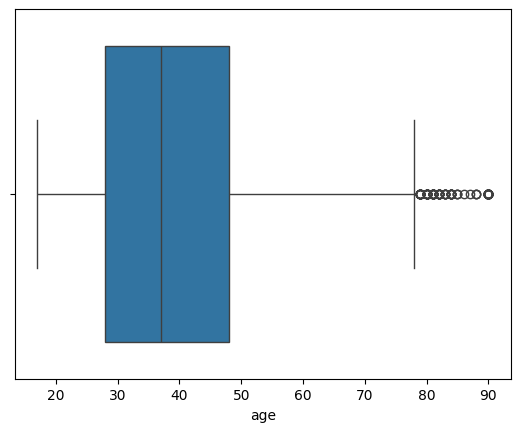

In [ ]:
sns.boxplot(x = df['age'])

#### As you can see in the above boxplot, there are some outliers in age variable

### Outlier Removal in age Column

In [ ]:
Q1 = df.age.quantile(0.25)
Q3 = df.age.quantile(0.75)
Q1, Q3

(np.float64(28.0), np.float64(48.0))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(20.0)

In [ ]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(-2.0), np.float64(78.0))

#### Outlier records

In [ ]:
df[(df.age<lower_limit)|(df.age> upper_limit)]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
118,83,Self-emp-inc,153183,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2392,55,United-States,>50K
128,81,Private,177408,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2377,26,United-States,>50K
199,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,2206,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31939,82,Self-emp-not-inc,71438,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
32305,90,Private,313749,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,25,United-States,<=50K
32468,85,Private,98611,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,3,Poland,<=50K
32500,82,?,403910,HS-grad,9,Never-married,?,Not-in-family,White,Male,0,0,3,United-States,<=50K


#### Removing the outlier

In [ ]:
df = df[(df.age>lower_limit)&(df.age<upper_limit)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32395 entries, 2 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32395 non-null  int64 
 1   workclass       32395 non-null  object
 2   fnlwgt          32395 non-null  int64 
 3   education       32395 non-null  object
 4   education.num   32395 non-null  int64 
 5   marital.status  32395 non-null  object
 6   occupation      32395 non-null  object
 7   relationship    32395 non-null  object
 8   race            32395 non-null  object
 9   sex             32395 non-null  object
 10  capital.gain    32395 non-null  int64 
 11  capital.loss    32395 non-null  int64 
 12  hours.per.week  32395 non-null  int64 
 13  native.country  32395 non-null  object
 14  income          32395 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


#### Handling workclass column

In [ ]:
df.workclass.unique()

array(['?', 'Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
df['workclass'].mode()

,workclass
0,Private


In [ ]:
def replace(col):
    if col == '?':
        return 'Private'
    else:
        return col

df['workclass'] = df['workclass'].apply(replace)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
2,66,Private,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [ ]:
df = pd.get_dummies(df, columns=['workclass'], drop_first = True)
df.head()

,age,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,...,hours.per.week,native.country,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
2,66,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
3,54,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
4,41,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,...,40,United-States,<=50K,False,False,True,False,False,False,False
5,34,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,...,45,United-States,<=50K,False,False,True,False,False,False,False
6,38,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,...,40,United-States,<=50K,False,False,True,False,False,False,False


#### Handling education column

In [ ]:
df.education.unique()

array(['Some-college', '7th-8th', 'HS-grad', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['education'], drop_first = True)
df.head()

,age,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college
2,66,186061,10,Widowed,?,Unmarried,Black,Female,0,4356,...,False,False,False,False,False,False,False,False,False,True
3,54,140359,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,False,False,False,False,False,False,False,False,False,True
5,34,216864,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,False,False,False,False,False,True,False,False,False,False
6,38,150601,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,False,False,False,False,False,False,False,False,False,False


#### Handling marital status column

In [ ]:
df['marital.status'].unique()

array(['Widowed', 'Divorced', 'Separated', 'Never-married',
       'Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['marital.status'], drop_first = True)
df.head()

,age,fnlwgt,education.num,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,...,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
2,66,186061,10,?,Unmarried,Black,Female,0,4356,40,...,False,False,False,True,False,False,False,False,False,True
3,54,140359,4,Machine-op-inspct,Unmarried,White,Female,0,3900,40,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Prof-specialty,Own-child,White,Female,0,3900,40,...,False,False,False,True,False,False,False,False,True,False
5,34,216864,9,Other-service,Unmarried,White,Female,0,3770,45,...,False,False,False,False,False,False,False,False,False,False
6,38,150601,6,Adm-clerical,Unmarried,White,Male,0,3770,40,...,False,False,False,False,False,False,False,False,True,False


#### Handling Occupation column

In [ ]:
df['occupation'].unique()

array(['?', 'Machine-op-inspct', 'Prof-specialty', 'Other-service',
       'Adm-clerical', 'Craft-repair', 'Exec-managerial',
       'Transport-moving', 'Handlers-cleaners', 'Sales',
       'Farming-fishing', 'Tech-support', 'Protective-serv',
       'Armed-Forces', 'Priv-house-serv'], dtype=object)

In [ ]:
df['occupation'].mode()

,occupation
0,Prof-specialty


In [ ]:
def change(col):
    if col == '?':
        return 'Prof-specialty'
    else:
        return col

df['occupation'] = df['occupation'].apply(change)
df.head()

,age,fnlwgt,education.num,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,...,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
2,66,186061,10,Prof-specialty,Unmarried,Black,Female,0,4356,40,...,False,False,False,True,False,False,False,False,False,True
3,54,140359,4,Machine-op-inspct,Unmarried,White,Female,0,3900,40,...,False,False,False,False,False,False,False,False,False,False
4,41,264663,10,Prof-specialty,Own-child,White,Female,0,3900,40,...,False,False,False,True,False,False,False,False,True,False
5,34,216864,9,Other-service,Unmarried,White,Female,0,3770,45,...,False,False,False,False,False,False,False,False,False,False
6,38,150601,6,Adm-clerical,Unmarried,White,Male,0,3770,40,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
df = pd.get_dummies(df, columns=['occupation'], drop_first = True)
df.head()

,age,fnlwgt,education.num,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
2,66,186061,10,Unmarried,Black,Female,0,4356,40,United-States,...,False,False,False,False,False,True,False,False,False,False
3,54,140359,4,Unmarried,White,Female,0,3900,40,United-States,...,False,False,True,False,False,False,False,False,False,False
4,41,264663,10,Own-child,White,Female,0,3900,40,United-States,...,False,False,False,False,False,True,False,False,False,False
5,34,216864,9,Unmarried,White,Female,0,3770,45,United-States,...,False,False,False,True,False,False,False,False,False,False
6,38,150601,6,Unmarried,White,Male,0,3770,40,United-States,...,False,False,False,False,False,False,False,False,False,False


#### Handling relationship column

In [ ]:
df['relationship'].unique()

array(['Unmarried', 'Own-child', 'Other-relative', 'Not-in-family',
       'Husband', 'Wife'], dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['relationship'], drop_first = True)
df.head()

,age,fnlwgt,education.num,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,Black,Female,0,4356,40,United-States,<=50K,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,White,Female,0,3900,40,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,White,Female,0,3900,40,United-States,<=50K,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,White,Female,0,3770,45,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,White,Male,0,3770,40,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,False


#### Handling Race column

##### Race Won't be a deciding factor for income. So, I am going to Drop that column

In [ ]:
df.drop('race', axis = 1, inplace = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Local-gov,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,Female,0,4356,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,Female,0,3900,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,Female,0,3900,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,Female,0,3770,45,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,Male,0,3770,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False


#### Handling Sex Column

In [ ]:
df['sex'] = pd.get_dummies(df['sex'], drop_first=True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Local-gov,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
2,66,186061,10,False,0,4356,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,False,True,False
3,54,140359,4,False,0,3900,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
4,41,264663,10,False,0,3900,40,United-States,<=50K,False,...,True,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False
6,38,150601,6,True,0,3770,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,True,False


#### Handling native.country column

In [ ]:
df['native.country'].unique()

array(['United-States', '?', 'Mexico', 'Greece', 'Vietnam', 'China',
       'Taiwan', 'India', 'Philippines', 'Trinadad&Tobago', 'Canada',
       'South', 'Holand-Netherlands', 'Puerto-Rico', 'Poland', 'Iran',
       'England', 'Germany', 'Italy', 'Japan', 'Hong', 'Honduras', 'Cuba',
       'Ireland', 'Cambodia', 'Peru', 'Nicaragua', 'Dominican-Republic',
       'Haiti', 'El-Salvador', 'Columbia', 'Guatemala', 'Jamaica',
       'France', 'Yugoslavia', 'Hungary', 'Scotland', 'Portugal',
       'Ecuador', 'Laos', 'Thailand', 'Outlying-US(Guam-USVI-etc)'],
      dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['native.country'], drop_first = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
2,66,186061,10,False,0,4356,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,False,0,3900,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,False,0,3900,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,True,0,3770,40,<=50K,False,False,...,False,False,False,False,False,False,False,True,False,False


### Handling Income Column

In [ ]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
df['income'] = pd.get_dummies(df['income'],drop_first = True)
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
2,66,186061,10,False,0,4356,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,False,0,3900,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,False,0,3900,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,216864,9,False,0,3770,45,False,False,False,...,False,False,False,False,False,False,False,True,False,False
6,38,150601,6,True,0,3770,40,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32395 entries, 2 to 32560
Data columns (total 95 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   age                                        32395 non-null  int64
 1   fnlwgt                                     32395 non-null  int64
 2   education.num                              32395 non-null  int64
 3   sex                                        32395 non-null  bool 
 4   capital.gain                               32395 non-null  int64
 5   capital.loss                               32395 non-null  int64
 6   hours.per.week                             32395 non-null  int64
 7   income                                     32395 non-null  bool 
 8   workclass_Local-gov                        32395 non-null  bool 
 9   workclass_Never-worked                     32395 non-null  bool 
 10  workclass_Private                          32395 no

### To move the income column to last

In [ ]:
df1 = df.pop('income')
df['income'] = df1
df.head()

,age,fnlwgt,education.num,sex,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income
2,66,186061,10,False,0,4356,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,54,140359,4,False,0,3900,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,41,264663,10,False,0,3900,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False
5,34,216864,9,False,0,3770,45,False,False,True,...,False,False,False,False,False,False,True,False,False,False
6,38,150601,6,True,0,3770,40,False,False,True,...,False,False,False,False,False,False,True,False,False,False


### Now Our Dataset is ready for Modelling

# Training Model

In [ ]:
X = df.iloc[:,:-1].values
print(X)

[[66 186061 10 ... True False False]
 [54 140359 4 ... True False False]
 [41 264663 10 ... True False False]
 ...
 [40 154374 9 ... True False False]
 [58 151910 9 ... True False False]
 [22 201490 9 ... True False False]]


In [ ]:
y = df.iloc[:,-1].values
print(y)

[False False False ...  True False False]


### Splitting dataset into Training and Test set

In [ ]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train_raw)
X_test = sc.fit_transform(X_test_raw)

### Training Model using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

### Making confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[4585  321]
 [ 644  929]]


0.8510572619231362

### Applying K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator=classifier , X=X_train , y=y_train , cv=10)
print('Accuracy: {:.2f} %'.format(accuracies.mean()*100))
print('Standard deviation: {:.2f} %'.format(accuracies.std()*100))

Accuracy: 84.97 %
Standard deviation: 0.66 %


### RandomSearch CV (Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {"C":np.logspace(-3,3,7), "penalty":["l1","l2"]}
grid = RandomizedSearchCV(classifier, param_grid,cv=10, random_state = 0)
grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

RandomizedSearchCV(cv=10, estimator=LogisticRegression(random_state=0),
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                                        'penalty': ['l1', 'l2']},
                   random_state=0)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'penalty': 'l2', 'C': np.float64(1.0)}
LogisticRegression(C=np.float64(1.0), random_state=0)


### Training Model After Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(penalty = 'l2', C=100, random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(C=100, random_state=0)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[4583  323]
 [ 646  927]]


0.8504398826979472

### Our Final Model accuracy is 85.059%

Gender:

In [ ]:
feature_names = df.drop("income", axis=1).columns
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_test_array = np.array(y_test)

for group_value in X_test_df["sex"].unique():
    idx = X_test_df["sex"] == group_value

    y_true_group = y_test_array[idx]
    y_pred_group = y_pred[idx]

    cm = confusion_matrix(y_true_group, y_pred_group)
    acc = accuracy_score(y_true_group, y_pred_group)

    print(f"sex = {group_value}")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", acc)
    print("-" * 40)

sex = -1.4425106237622805
Confusion Matrix:
[[1817   51]
 [ 117  118]]
Accuracy: 0.920114122681883
----------------------------------------
sex = 0.693235795651754
Confusion Matrix:
[[2766  272]
 [ 529  809]]
Accuracy: 0.8169561243144424
----------------------------------------
